In [40]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import cm
import seaborn as sns

In [41]:
cell_cycle = pd.read_csv('/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv') 
x = cell_cycle["PHATE_1"]
y = cell_cycle["PHATE_2"]
labels = cell_cycle['phase']

rf_loco = pd.read_csv('/Users/mariahloehr/IICD/IICD/LOCO/rf_loco_full.csv')
xgb_loco = pd.read_csv('/Users/mariahloehr/IICD/IICD/LOCO/xgb_loco_full.csv')
mlp_loco = pd.read_csv('/Users/mariahloehr/IICD/IICD/LOCO/mlp_loco_full.csv')

In [133]:
feature = rf_loco[["feature_name"]]

df1_no_ref = rf_loco.drop(columns="feature_name")
df2_no_ref = xgb_loco.drop(columns="feature_name")
df3_no_ref = mlp_loco.drop(columns="feature_name")

summed = df1_no_ref + df2_no_ref + df3_no_ref

merged = pd.concat([feature, summed], axis=1)


In [134]:
merged.sort_values(by = "score", axis=0, ascending=True).head(n=10)

,feature_name,0,1,lower_bound,upper_bound,score
114,p14ARF..PN.median.,3.0,1.000433,-0.010016,-0.001158,-0.005587
236,AKT..phospho.total.nuc.,3.0,0.064129,-0.009714,-0.000925,-0.005320
88,E2F1..PM.median.,3.0,1.177817,-0.009693,-0.000881,-0.005287
144,p27 (cytoplasm),3.0,1.001083,-0.009307,-0.000742,-0.005025
173,pAKT (cytoplasm),3.0,1.000010,-0.009048,-0.000585,-0.004816
222,p27..phospho.total.cell.,3.0,2.000000,-0.008988,-0.000516,-0.004752
243,p53..phospho.total.nuc.,3.0,1.002224,-0.009297,-0.000129,-0.004713
233,p53..phospho.total.cyto.,3.0,1.000000,-0.008922,-0.000188,-0.004555
110,CDK4..cell.median.,3.0,1.037684,-0.009142,0.000156,-0.004493
194,pp27 (cytoplasm),3.0,1.556579,-0.008955,0.000225,-0.004365


In [11]:
merged.loc[merged['feature_name'] == "E2F1 (nucleus)", 'score']

0    0.072134
Name: score, dtype: float64

In [14]:
cell_cycle

,E2F1..nuc.median.,cycA..nuc.median.,cycD1..nuc.median.,p21..nuc.median.,Int_Intg_DNA_nuc,Skp2..nuc.median.,Cdt1..nuc.median.,Nuc.area,Cdh1..nuc.median.,cycE..nuc.median.,...,cycD1_over_p21,cyto_over_DNA,CDK2_cyto_over_nuc,STAT3..phospho.total.nuc.,age,phase,PHATE_1,PHATE_2,Local.cell.density,ratio
0,-0.725044,-0.491015,0.821794,3.469768,-0.203444,-0.835392,-0.599459,0.990347,1.324805,0.182174,...,-2.056760,0.942707,-0.160688,1.074052,10.263173,G0,-0.020654,0.007907,-1.454632,-2.174521
1,1.099286,2.402916,-0.939193,-0.716495,1.228120,1.617212,-0.400448,0.496622,1.581834,-0.210004,...,-0.287614,0.153741,0.236513,0.616793,12.109644,S,0.025945,-0.000735,-2.680782,0.196887
2,-0.583545,-0.512819,-1.066736,-0.848878,-0.570350,0.499366,-0.656865,-0.498666,-1.153217,0.116811,...,-0.130171,-0.211941,-0.020622,0.376084,4.954907,G1,0.002961,-0.004575,-1.658990,0.320159
3,-0.831169,0.902432,-0.659493,-0.341408,1.972391,1.075504,-0.580323,1.194107,-0.107526,-0.784511,...,-0.706768,-0.756567,-0.533029,0.586613,13.424587,G2,0.034884,0.002944,-1.045915,0.387470
4,-0.760419,-0.471194,-0.708721,-0.528216,-0.432919,-0.244334,0.062635,-1.023738,-0.241533,-0.492097,...,-0.327084,-0.225607,0.906354,0.341149,1.828240,G0,-0.019039,0.000584,-2.272065,-0.160910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8845,0.017827,-0.438489,0.022973,0.060156,-0.408151,-0.908843,0.632877,-0.780794,0.030874,0.075529,...,-0.373984,-0.799081,-0.187392,0.741001,3.449547,G1,-0.018843,0.000029,-1.027523,0.415727
8846,-0.735151,1.166058,1.016465,-0.512036,1.768134,0.767925,-0.364090,1.288150,-0.379933,-0.595302,...,3.573499,-0.520197,-0.489181,1.665656,14.993973,G2,0.039467,0.006623,-0.659678,0.571866
8847,-0.568384,-0.566337,-0.040799,-0.307577,-0.637739,-0.636842,-0.427238,-1.094271,0.087991,-0.388893,...,0.402510,1.039852,1.710491,0.216095,1.683893,G1,-0.021200,0.000573,-0.688288,0.473061
8848,-0.085771,0.452485,-0.199668,-0.506152,1.162679,1.472603,0.232942,0.441763,0.760221,-0.172162,...,0.766311,1.605684,1.935152,9.316236,12.225778,S,0.027874,-0.000248,-0.577935,0.728528


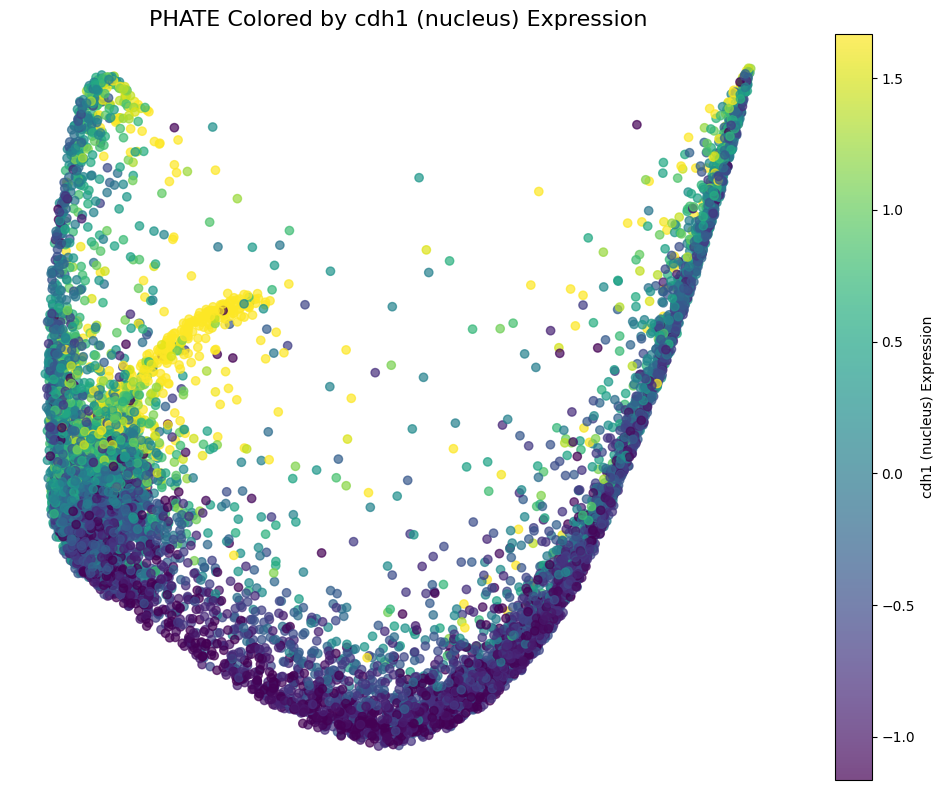

In [52]:
protein_expression = cell_cycle["Cdh1..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [5, 95])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by cdh1 (nucleus) Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("cdh1 (nucleus) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_cdh1.png"
plt.savefig(filename, dpi=300)
plt.show()

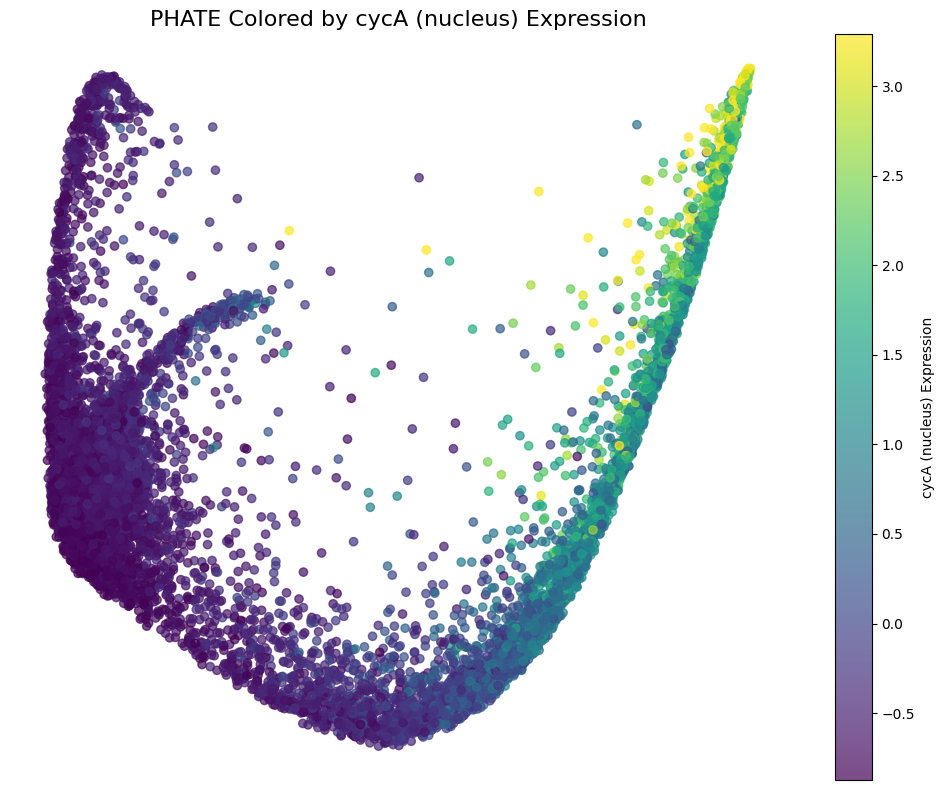

In [108]:
protein_expression = cell_cycle["cycA..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by cycA (nucleus) Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("cycA (nucleus) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_cycA.png"
plt.savefig(filename, dpi=300)
plt.show()

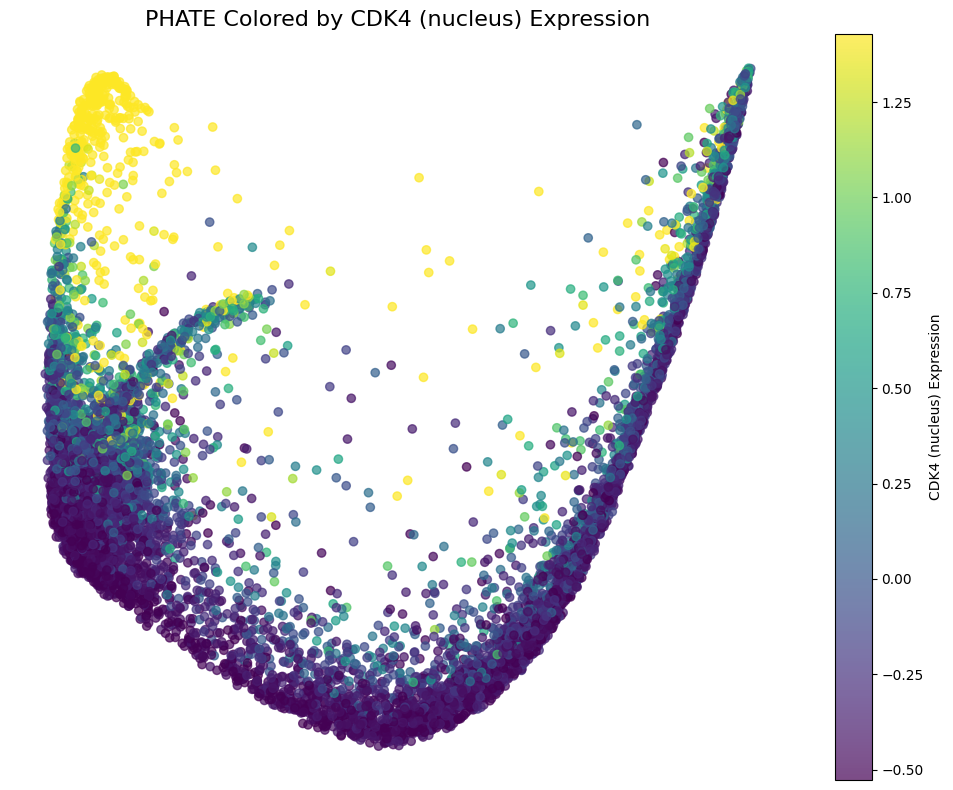

In [43]:
protein_expression = cell_cycle["CDK4..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [5, 95])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by CDK4 (nucleus) Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("CDK4 (nucleus) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
#filename = "phate_by_cdk4.png"
#plt.savefig(filename, dpi=300)
plt.show()

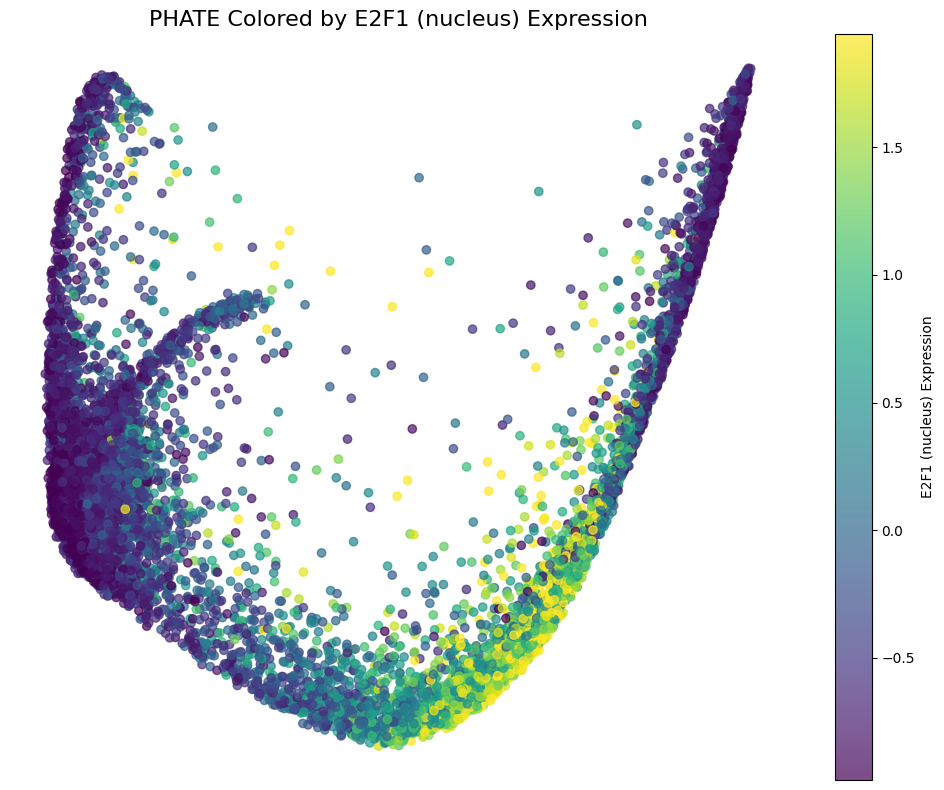

In [51]:
protein_expression = cell_cycle["E2F1..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [5, 95])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by E2F1 (nucleus) Expression', fontsize=16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("E2F1 (nucleus) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_e2f1.png"
plt.savefig(filename, dpi=300)
plt.show()

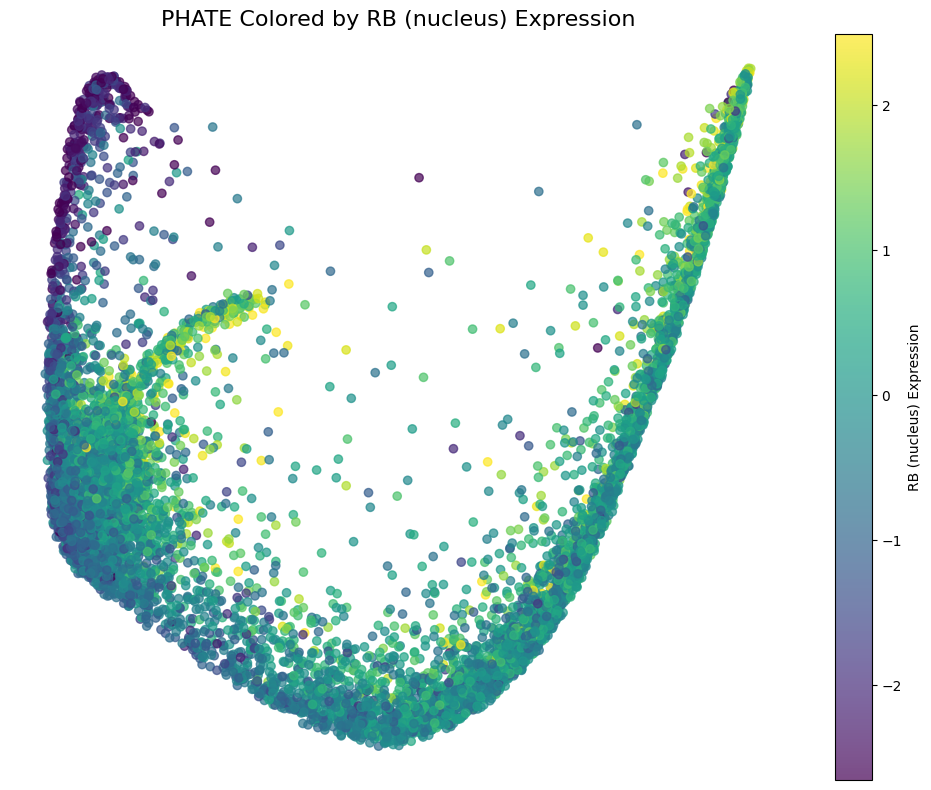

In [112]:
protein_expression = cell_cycle["RB..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by RB (nucleus) Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("RB (nucleus) Expression")
plt.grid(True)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_RB.png"
plt.savefig(filename, dpi=300)
plt.show()

iLOCO

In [4]:
rf_iloco = pd.read_csv('/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_decisionTree.csv')
xgb_iloco = pd.read_csv('/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_xgb.csv')
mlp_iloco = pd.read_csv('/Users/mariahloehr/IICD/IICD/LOCO/iLOCO/iloco_mlp.csv')

In [7]:
feature = rf_iloco[["feature"]]

df1_no_ref = rf_iloco.drop(columns="feature")
df2_no_ref = xgb_iloco.drop(columns="feature")
df3_no_ref = mlp_iloco.drop(columns="feature")

summed = df1_no_ref + df2_no_ref + df3_no_ref

merged = pd.concat([feature, summed], axis=1)

merged.sort_values(by = "scores", axis=0, ascending=False).head(n=10)


,feature,scores,ci
267,cycA..nuc.median. & Cdh1..nuc.median.,0.042096,0.279885
1030,p21..nuc.median. & p38..phospho.total.PN.,0.035929,0.062172
3,E2F1..nuc.median. & Int_Intg_DNA_nuc,0.033094,0.070166
17212,Skp2..cyto.median. & p38..cell.median.,0.031173,0.036910
24310,Cdt1..PM.median. & p21..phospho.total.PN.,0.031154,0.043552
6374,CDK2..nuc.median. & DNA..cyto.median.,0.031066,0.065188
20643,Skp2..PN.median. & p38..phospho.total.nuc.,0.028347,0.036162
14539,pERK..PM.median. & RB..cell.median.,0.027941,0.043179
4420,pRB..nuc.median. & p21..PN.median.,0.027869,0.038216
22599,p38..cyto.median. & CDK6..PN.median.,0.027772,0.040249


In [8]:
rf_iloco.sort_values(by = "scores", axis=0, ascending=False).head(n=10)

,feature,scores,ci
267,cycA..nuc.median. & Cdh1..nuc.median.,0.030959,0.112921
794,p21..nuc.median. & cycB1..nuc.median.,0.026654,0.026524
1030,p21..nuc.median. & p38..phospho.total.PN.,0.022315,0.026524
33624,ERK..phospho.total.cyto. & cycD1_over_p21,0.022076,0.014782
13492,pERK..cell.median. & E2F1..cyto.median.,0.021714,0.014503
17591,CDK2..PN.median. & pSTAT3..PN.median.,0.021710,0.013776
29718,cFos..PM.median. & p38..phospho.total.PN.,0.020245,0.014298
15117,E2F1..cyto.median. & GSK3b..PN.median.,0.020195,0.016799
6004,pp21..nuc.median. & cycD1..cell.median.,0.019657,0.022150
28370,YAP..PN.median. & RB..phospho.total.cell.,0.019625,0.014690


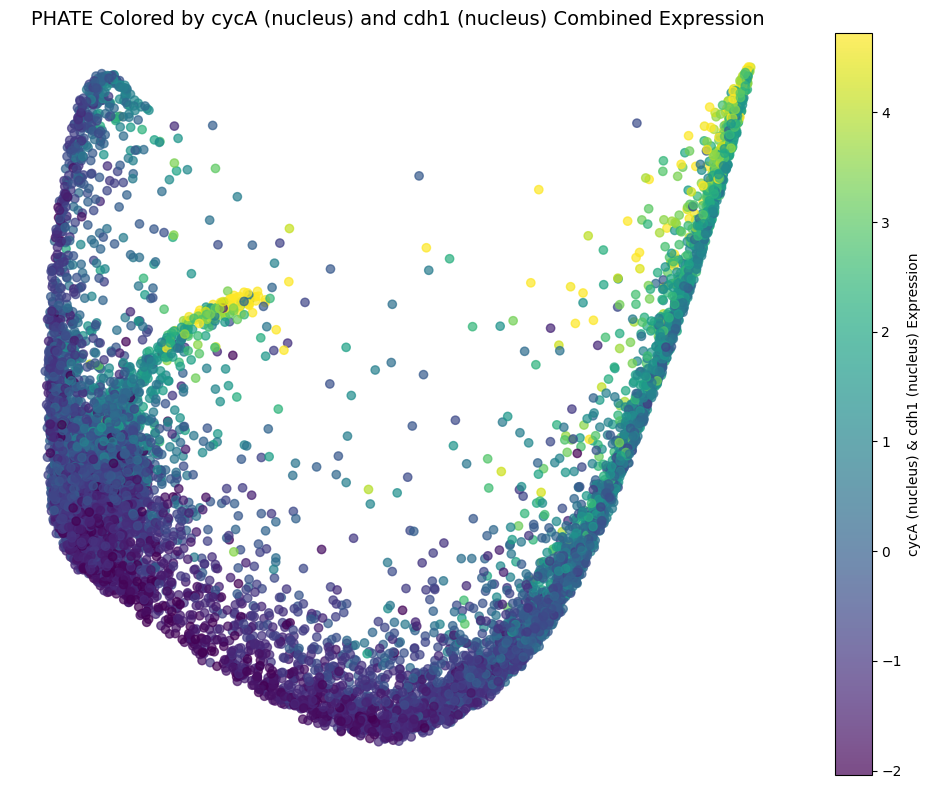

In [114]:
cell_cycle["cycA..nuc.median. & Cdh1..nuc.median."] = cell_cycle["cycA..nuc.median."] + cell_cycle["Cdh1..nuc.median."]
protein_expression = cell_cycle["cycA..nuc.median. & Cdh1..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by cycA (nucleus) and cdh1 (nucleus) Combined Expression', fontsize = 14)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("cycA (nucleus) & cdh1 (nucleus) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_cycA_cdh1.png"
plt.savefig(filename, dpi=300)
plt.show()

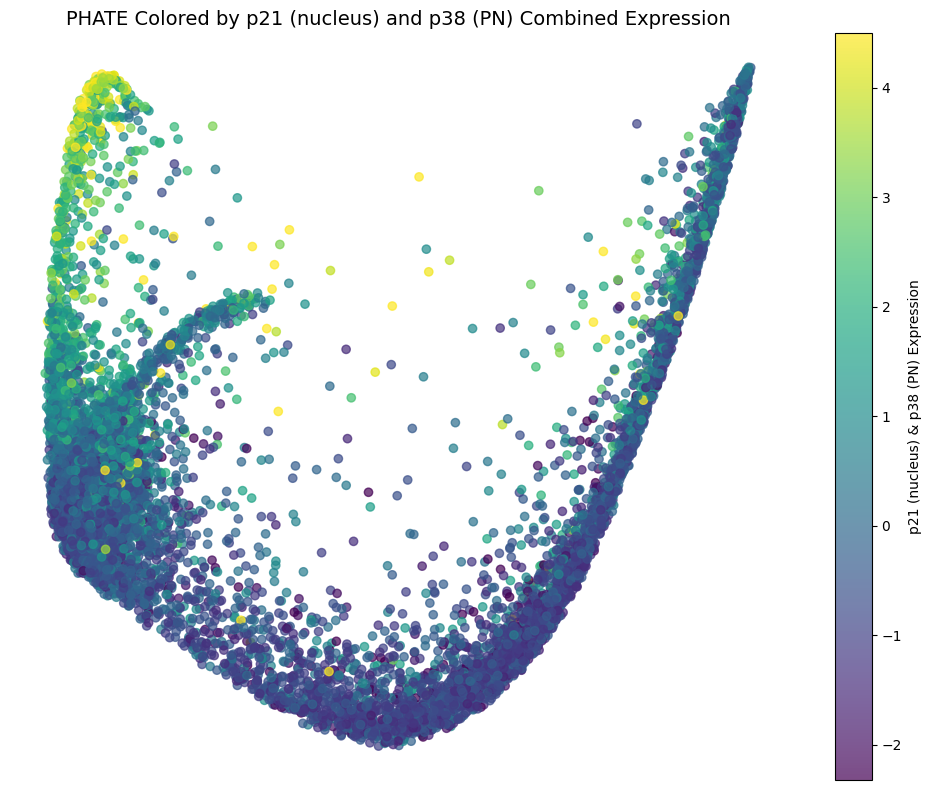

In [106]:
cell_cycle["p21..nuc.median. & p38..phospho.total.PN."] = cell_cycle["p21..nuc.median."] + cell_cycle["p38..phospho.total.PN."]
protein_expression = cell_cycle["p21..nuc.median. & p38..phospho.total.PN."]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by p21 (nucleus) and p38 (PN) Combined Expression', fontsize = 14)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("p21 (nucleus) & p38 (PN) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_p21_p38.png"
plt.savefig(filename, dpi=300)
plt.show()

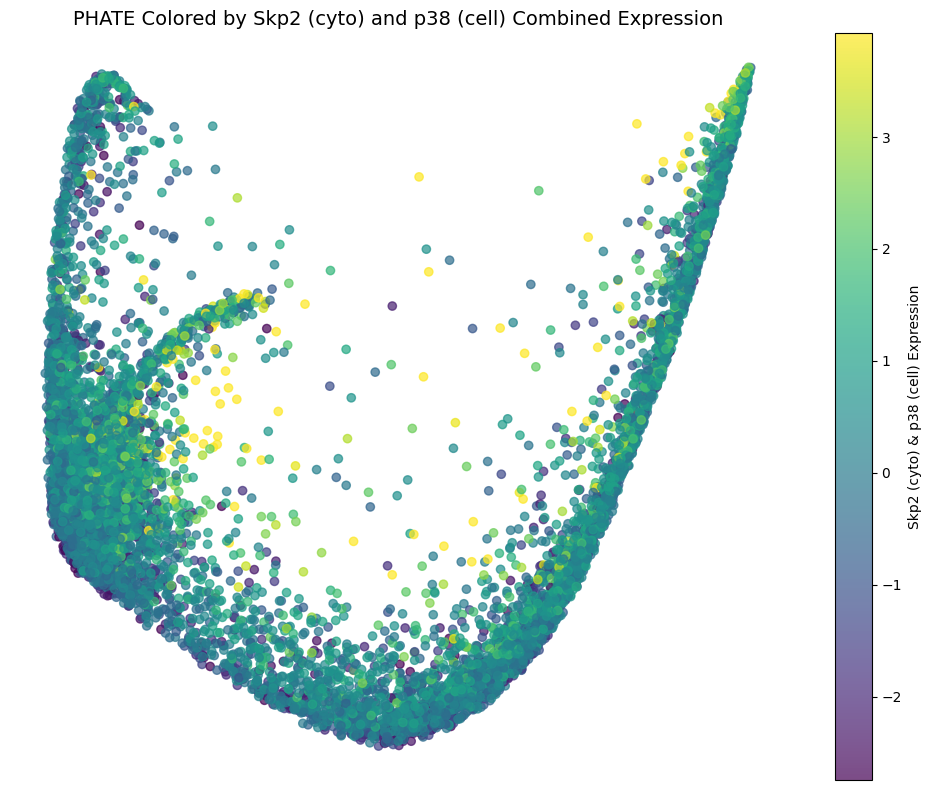

In [103]:
cell_cycle["Skp2..cyto.median. & p38..cell.median."] = cell_cycle["Skp2..cyto.median."] + cell_cycle["p38..cell.median."]
protein_expression = cell_cycle["Skp2..cyto.median. & p38..cell.median."]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin =vmin, vmax = vmax, alpha=0.7)
plt.title(f'PHATE Colored by Skp2 (cyto) and p38 (cell) Combined Expression', fontsize = 14)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("Skp2 (cyto) & p38 (cell) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_skp2_p38.png"
plt.savefig(filename, dpi=300)
plt.show()

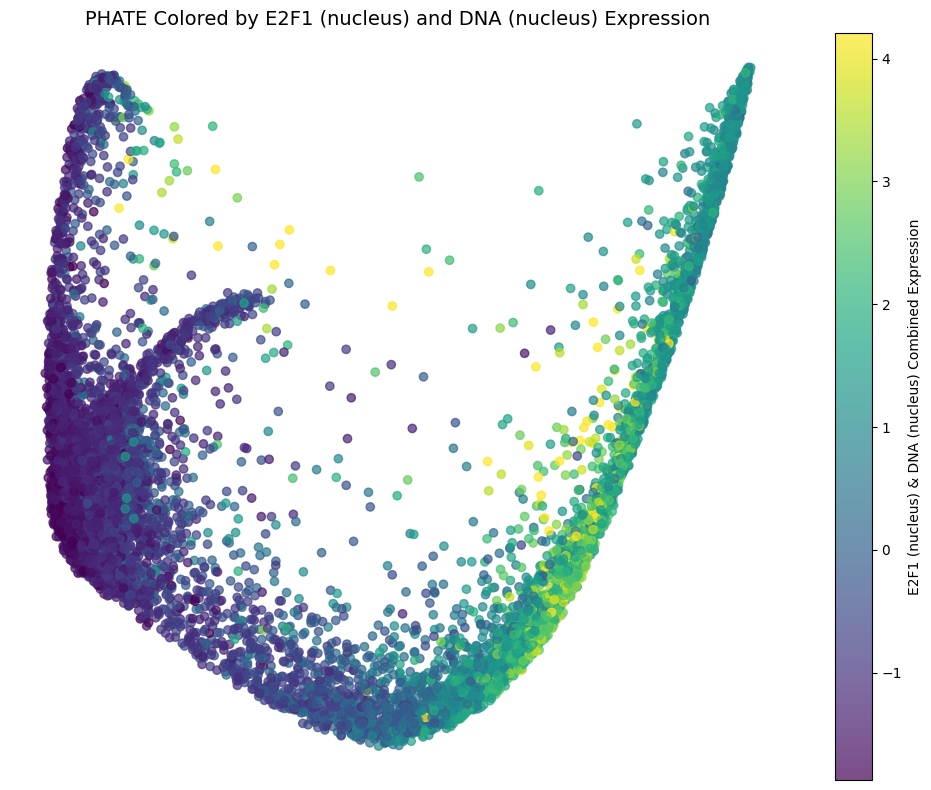

In [104]:
cell_cycle["E2F1..nuc.median. & Int_Intg_DNA_nuc"] = cell_cycle["E2F1..nuc.median."] + cell_cycle["Int_Intg_DNA_nuc"]
protein_expression = cell_cycle["E2F1..nuc.median. & Int_Intg_DNA_nuc"]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin =vmin, vmax = vmax, alpha=0.7)
plt.title(f'PHATE Colored by E2F1 (nucleus) and DNA (nucleus) Expression', fontsize = 14)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("E2F1 (nucleus) & DNA (nucleus) Combined Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_E2F1_DNA.png"
plt.savefig(filename, dpi=300)
plt.show()

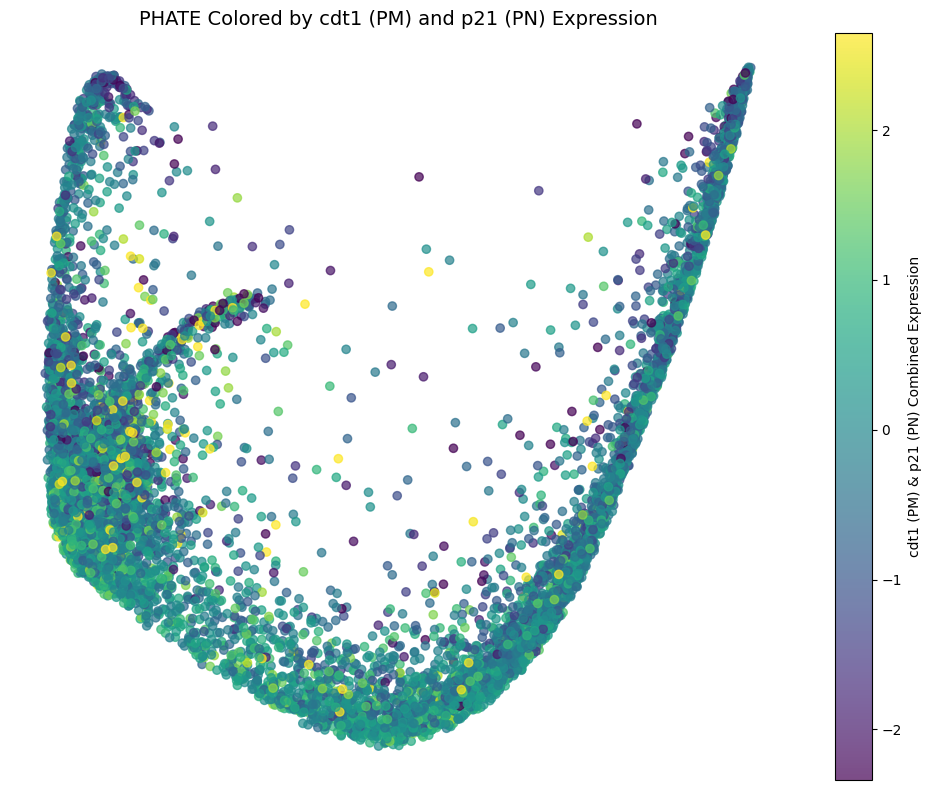

In [128]:
cell_cycle["Cdt1..PM.median. & p21..phospho.total.PN."] = cell_cycle["Cdt1..PM.median."] + cell_cycle["p21..phospho.total.PN."]
protein_expression = cell_cycle["Cdt1..PM.median. & p21..phospho.total.PN."]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin =vmin, vmax = vmax, alpha=0.7)
plt.title(f'PHATE Colored by cdt1 (PM) and p21 (PN) Expression', fontsize = 14)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("cdt1 (PM) & p21 (PN) Combined Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_cdt1_p21.png"
plt.savefig(filename, dpi=300)
plt.show()

RF iLOCO top 4

In [126]:
rf_iloco.sort_values(by = "scores", axis=0, ascending=False).head(n=10)

,feature,scores,ci
267,cycA..nuc.median. & Cdh1..nuc.median.,0.030959,0.112921
794,p21..nuc.median. & cycB1..nuc.median.,0.026654,0.026524
1030,p21..nuc.median. & p38..phospho.total.PN.,0.022315,0.026524
33624,ERK..phospho.total.cyto. & cycD1_over_p21,0.022076,0.014782
13492,pERK..cell.median. & E2F1..cyto.median.,0.021714,0.014503
17591,CDK2..PN.median. & pSTAT3..PN.median.,0.021710,0.013776
29718,cFos..PM.median. & p38..phospho.total.PN.,0.020245,0.014298
15117,E2F1..cyto.median. & GSK3b..PN.median.,0.020195,0.016799
6004,pp21..nuc.median. & cycD1..cell.median.,0.019657,0.022150
28370,YAP..PN.median. & RB..phospho.total.cell.,0.019625,0.014690


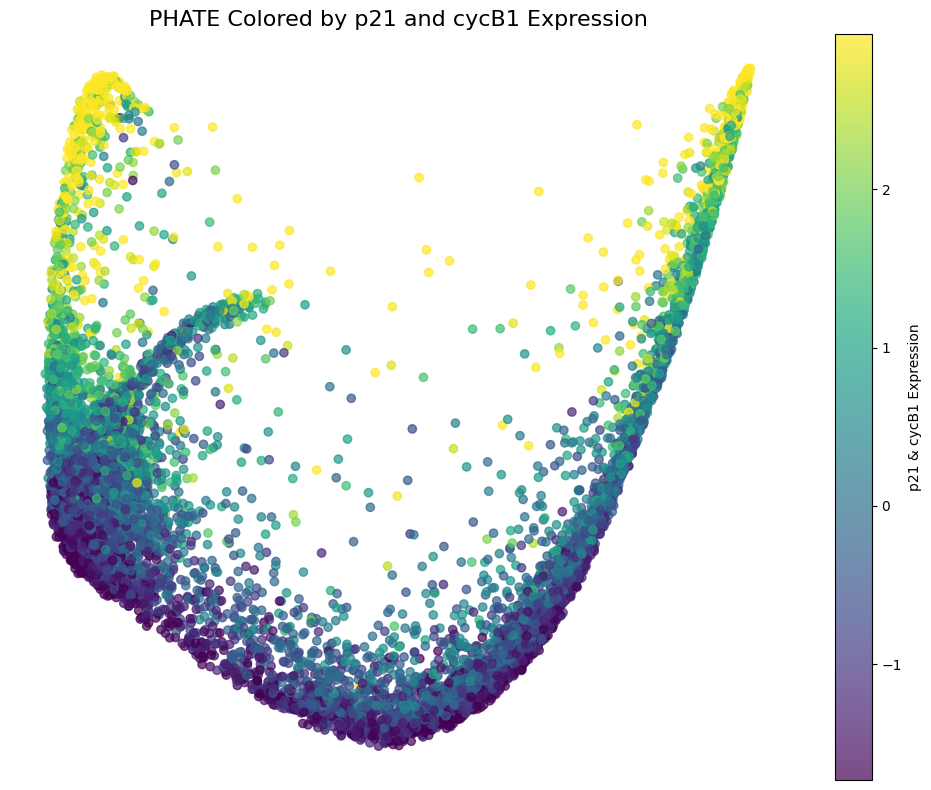

In [47]:
cell_cycle["p21..nuc.median. & cycB1..nuc.median."] = cell_cycle["p21..nuc.median."] + cell_cycle["cycB1..nuc.median."]
protein_expression = cell_cycle["p21..nuc.median. & cycB1..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [5, 95])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by p21 and cycB1 Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("p21 & cycB1 Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_p21_cycB1.png"
plt.savefig(filename, dpi=300)
plt.show()

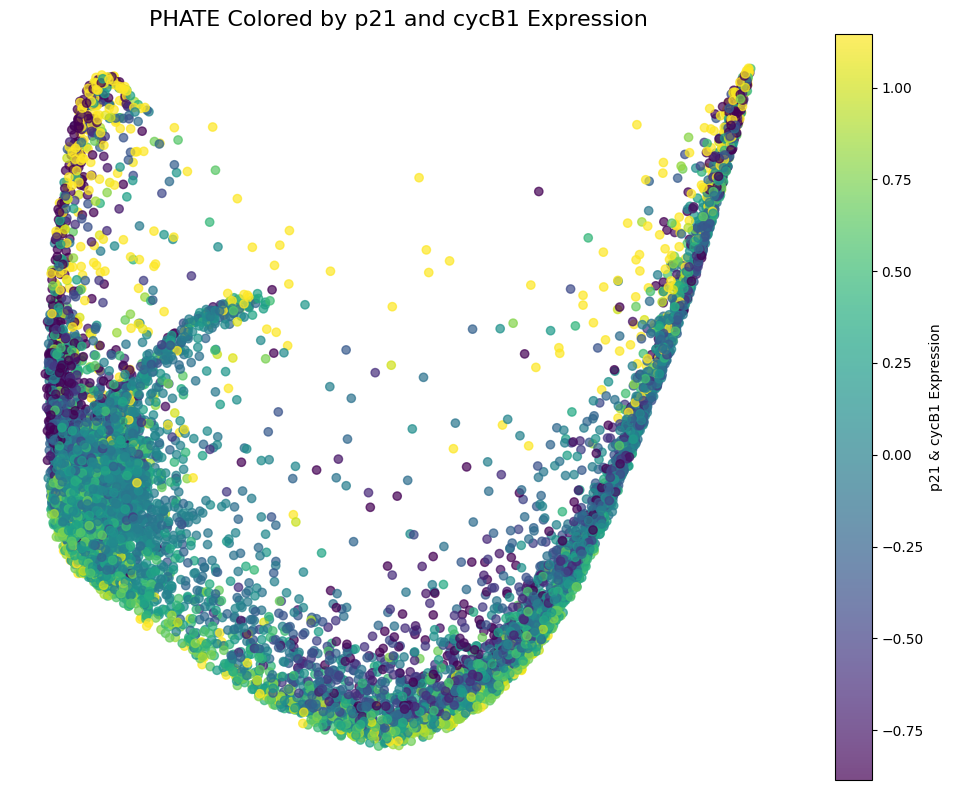

In [55]:
cell_cycle["p21..nuc.median. & cycB1..nuc.median."] = cell_cycle["p21..nuc.median."] * cell_cycle["cycB1..nuc.median."]
protein_expression = cell_cycle["p21..nuc.median. & cycB1..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [5, 95])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by p21 and cycB1 Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("p21 & cycB1 Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
#filename = "phate_by_p21_cycB1.png"
#plt.savefig(filename, dpi=300)
plt.show()

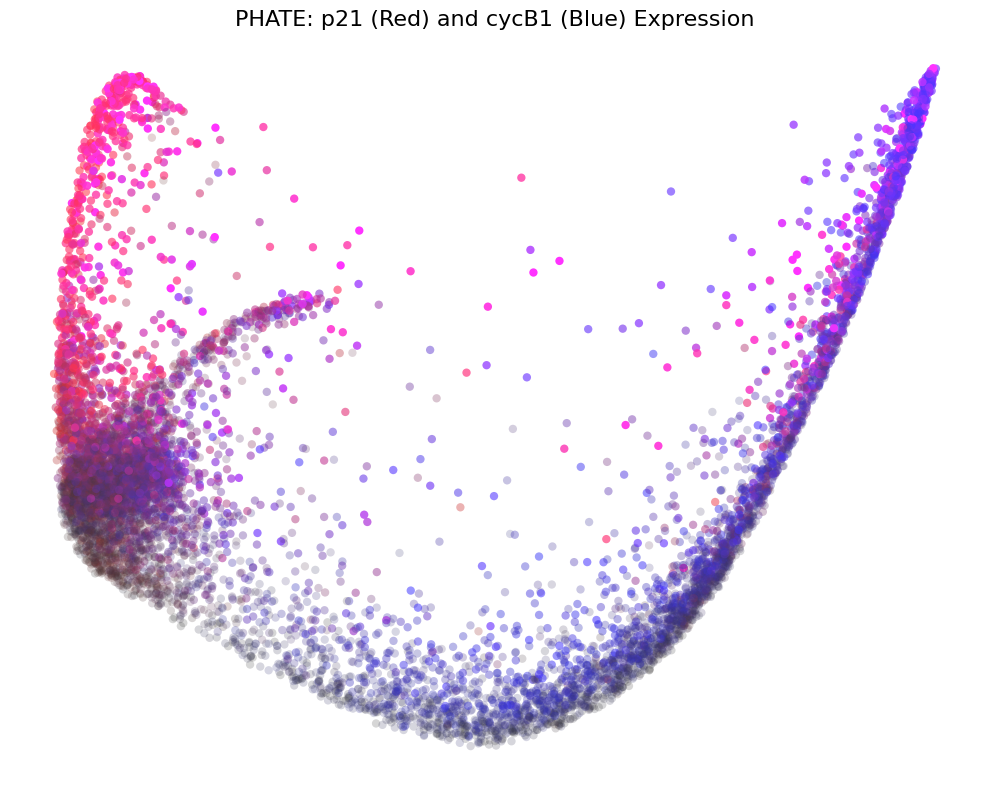

In [60]:
# Normalize each protein expression individually to [0, 1] using percentiles
p21 = cell_cycle["p21..nuc.median."]
cycB1 = cell_cycle["cycB1..nuc.median."]

p21_norm = (p21 - np.percentile(p21, 5)) / (np.percentile(p21, 95) - np.percentile(p21, 5))
cycB1_norm = (cycB1 - np.percentile(cycB1, 5)) / (np.percentile(cycB1, 95) - np.percentile(cycB1, 5))

# Clip values to stay in [0, 1]
p21_norm = np.clip(p21_norm, 0, 1)
cycB1_norm = np.clip(cycB1_norm, 0, 1)

# Add base brightness to avoid black background
base_level = 0.2
colors = np.stack([
    base_level + (1 - base_level) * p21_norm,   # Red
    np.full_like(p21_norm, base_level),         # Green fixed
    base_level + (1 - base_level) * cycB1_norm  # Blue
], axis=1)
colors = np.clip(colors, 0, 1)

# Optional: Alpha blending based on intensity
intensity = (p21_norm + cycB1_norm) / 2
alphas = np.clip(intensity, 0.2, 1.0)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(x, y, c=colors, alpha=alphas, edgecolor='none')
plt.title('PHATE: p21 (Red) and cycB1 (Blue) Expression', fontsize=16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
plt.axis('off')
plt.tight_layout()
plt.show()

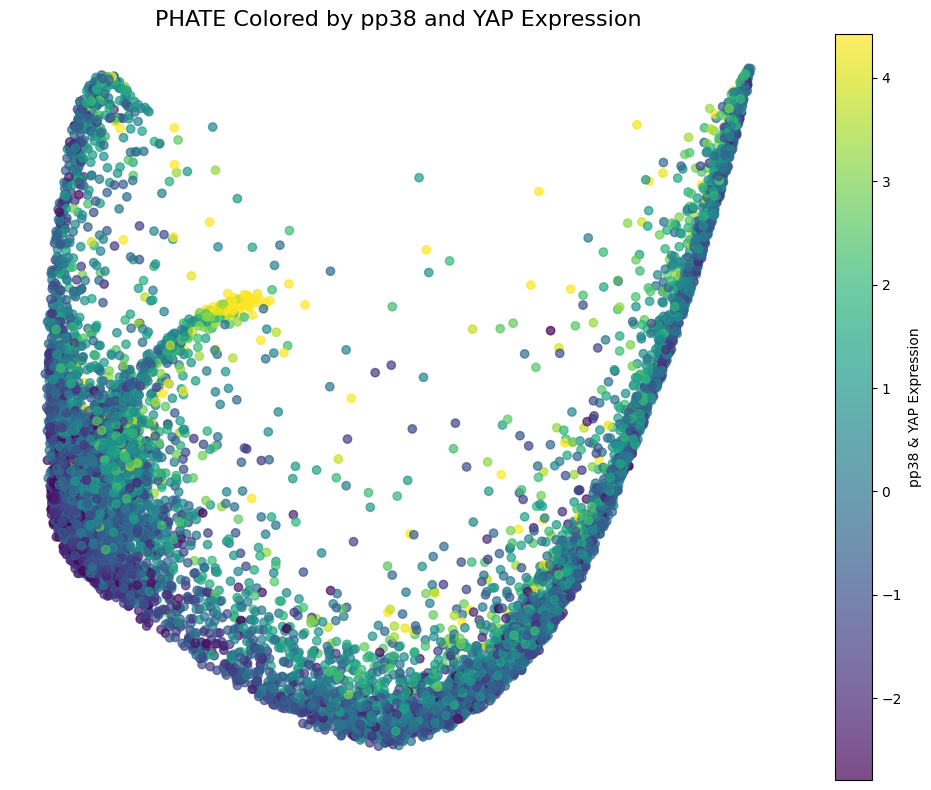

In [28]:
cell_cycle["pp38..nuc.median. & YAP..nuc.median."] = cell_cycle["pp38..nuc.median."] + cell_cycle["YAP..nuc.median."]
protein_expression = cell_cycle["pp38..nuc.median. & YAP..nuc.median."]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by pp38 and YAP Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("pp38 & YAP Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
filename = "phate_by_pp38_YAP.png"
plt.savefig(filename, dpi=300)
plt.show()

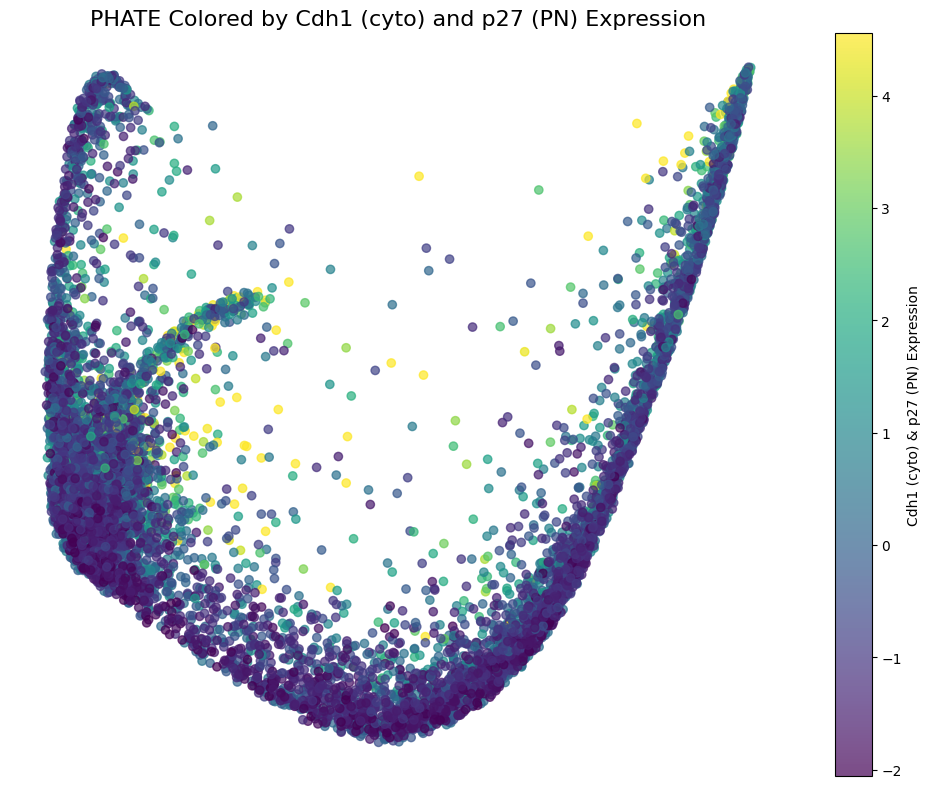

In [50]:
cell_cycle["Cdh1..cyto.median. & p27..PN.median."] = cell_cycle["Cdh1..cyto.median."] + cell_cycle["p27..PN.median."]
protein_expression = cell_cycle["Cdh1..cyto.median. & p27..PN.median."]

vmin, vmax = np.percentile(protein_expression, [1, 99])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by Cdh1 (cyto) and p27 (PN) Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("Cdh1 (cyto) & p27 (PN) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
#filename = "phate_by_cdh1_p27.png"
#plt.savefig(filename, dpi=300)
plt.show()

/var/folders/1s/bvxr71hj0hqgyk_jk6k7wkm80000gn/T/ipykernel_40999/2712240188.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  plt.scatter(x, y, c=colors, alpha=0.5, vmin=vmin, vmax=vmax, edgecolor='none')


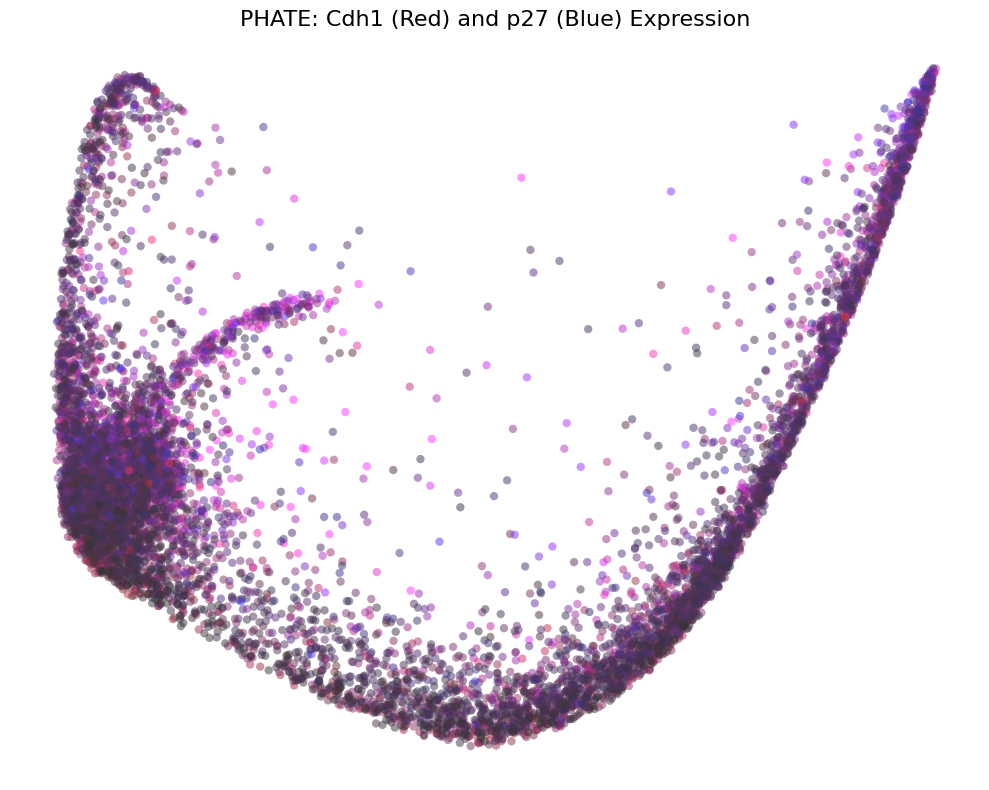

In [59]:
# Normalize both expressions between 0 and 1 (percentile-based for robustness)
cdh1_norm = (cell_cycle["Cdh1..cyto.median."] - np.percentile(cell_cycle["Cdh1..cyto.median."], 1)) / \
            (np.percentile(cell_cycle["Cdh1..cyto.median."], 99) - np.percentile(cell_cycle["Cdh1..cyto.median."], 1))

p27_norm = (cell_cycle["p27..PN.median."] - np.percentile(cell_cycle["p27..PN.median."], 1)) / \
           (np.percentile(cell_cycle["p27..PN.median."], 99) - np.percentile(cell_cycle["p27..PN.median."], 1))

# Clip to [0, 1] to keep within color bounds
cdh1_norm = np.clip(cdh1_norm, 0, 1)
p27_norm = np.clip(p27_norm, 0, 1)

# Combine into RGB colors: Cdh1 = Red, p27 = Blue
colors = np.stack([cdh1_norm, np.zeros_like(cdh1_norm), p27_norm], axis=1)

vmin, vmax = np.percentile(protein_expression, [5, 95])

background = 0.2  # adds 20% brightness to each channel
colors = np.stack([
    background + 0.8 * cdh1_norm,     # Red
    background + 0.0 * cdh1_norm,     # Green
    background + 0.8 * p27_norm       # Blue
], axis=1)
colors = np.clip(colors, 0, 1)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(x, y, c=colors, alpha=0.5, vmin=vmin, vmax=vmax, edgecolor='none')
plt.title('PHATE: Cdh1 (Red) and p27 (Blue) Expression', fontsize=16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
plt.axis('off')
plt.tight_layout()
plt.show()

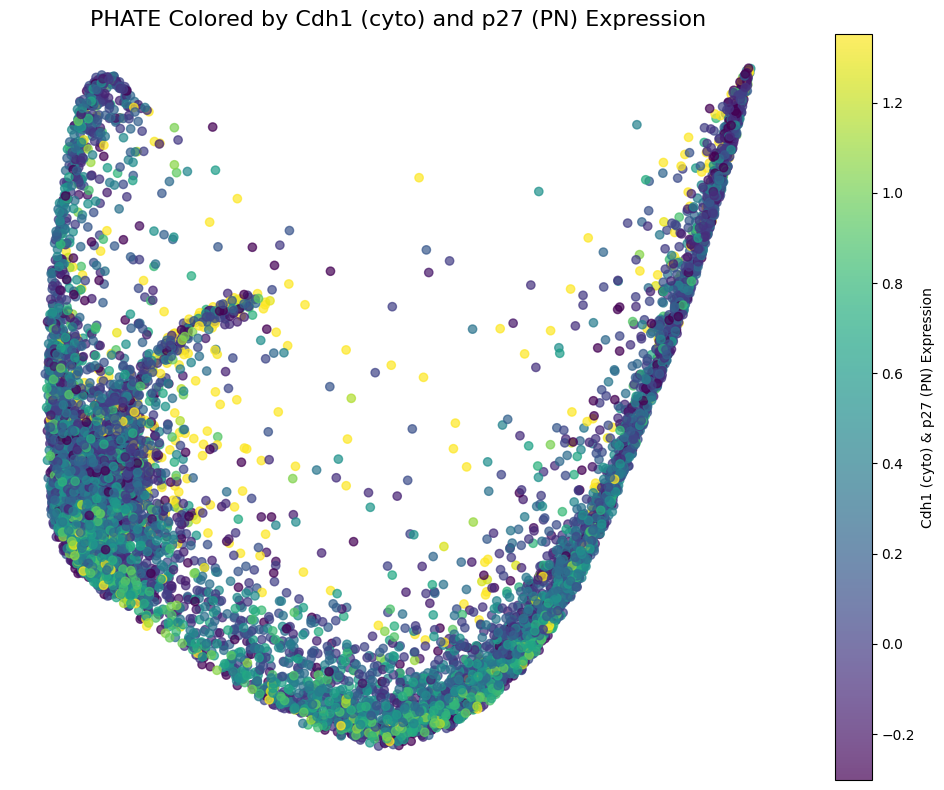

In [54]:
cell_cycle["Cdh1..cyto.median. & p27..PN.median."] = cell_cycle["Cdh1..cyto.median."] * cell_cycle["p27..PN.median."]
protein_expression = cell_cycle["Cdh1..cyto.median. & p27..PN.median."]

vmin, vmax = np.percentile(protein_expression, [5, 95])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(x, y, c=protein_expression, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.7)
plt.title(f'PHATE Colored by Cdh1 (cyto) and p27 (PN) Expression', fontsize = 16)
plt.xlabel('PHATE 1')
plt.ylabel('PHATE 2')
cbar = plt.colorbar(scatter)
cbar.set_label("Cdh1 (cyto) & p27 (PN) Expression")
plt.grid(False)
plt.axis('off')
plt.tight_layout()

# Save plot per protein
#filename = "phate_by_cdh1_p27.png"
#plt.savefig(filename, dpi=300)
plt.show()